<a href="https://colab.research.google.com/github/SadhanaGhodke/DSBDA/blob/main/A5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from matplotlib.colors import ListedColormap

In [2]:
 # Step 2: Import the Dataset
 dataset = pd.read_csv('/content/Social_Network_Ads.csv')
 # Step 3: Initialize DataFrame
 print(dataset.head())

   Age  EstimatedSalary  Purchased
0   19            19000          0
1   35            20000          0
2   26            43000          0
3   27            57000          0
4   19            76000          0


In [4]:
 # Step 4: Data Preprocessing
 # Convert Categorical to Numerical Values if applicable
 # Check for Null Values
 print(dataset.isnull().sum())
 # Covariance Matrix
 cov_matrix = dataset.cov()
 print(cov_matrix)
 # Divide the dataset into Independent (X) and Dependent (Y) variables
 X = dataset[['Age', 'EstimatedSalary']].values
 y = dataset['Purchased'].values
 # Split the dataset into Training and Testing sets (80% training, 20% testing)
 X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

Age                0
EstimatedSalary    0
Purchased          0
dtype: int64
                          Age  EstimatedSalary    Purchased
Age                109.890702     5.548738e+04     3.131165
EstimatedSalary  55487.380952     1.162603e+09  5924.367168
Purchased            3.131165     5.924367e+03     0.230269


In [7]:
# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
# Step 5: Train Logistic Regression Model
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
# Step 6: Predict the y_pred for train and test sets
y_train_pred = logreg.predict(X_train)
y_test_pred = logreg.predict(X_test)

In [8]:
 # Step 7: Evaluate the Performance
 train_accuracy = accuracy_score(y_train, y_train_pred)
 test_accuracy = accuracy_score(y_test, y_test_pred)
 print(f"Training Accuracy: {train_accuracy}")
 print(f"Test Accuracy: {test_accuracy}")

Training Accuracy: 0.821875
Test Accuracy: 0.925


In [14]:
 # Step 8: Calculate Evaluation Parameters
 cm = confusion_matrix(y_test, y_test_pred)
 print("\nConfusion Matrix (Test Data):")
 print(cm)
 precision = precision_score(y_test, y_test_pred)
 recall = recall_score(y_test, y_test_pred)
 f1 = f1_score(y_test, y_test_pred)
 print(f"Precision: {precision}")
 print(f"Recall: {recall}")
 print(f"F1 Score: {f1}")


Confusion Matrix (Test Data):
[[57  1]
 [ 5 17]]
Precision: 0.9444444444444444
Recall: 0.7727272727272727
F1 Score: 0.85


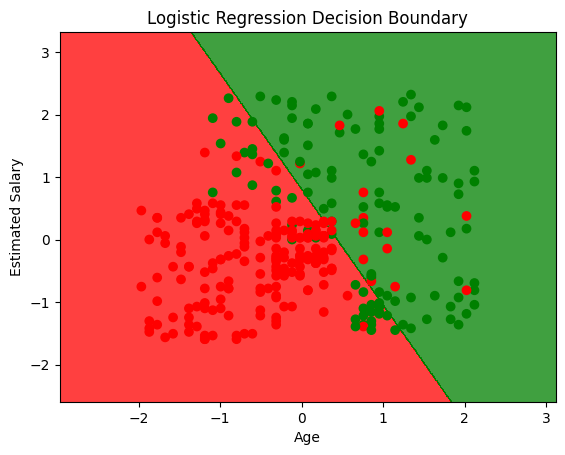

In [21]:
# Define the grid for visualization
X_set, y_set = X_train, y_train
X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
)

# Predict on the grid
Z = logreg.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape)

# Plot the decision boundary
plt.contourf(X1, X2, Z, alpha=0.75, cmap=ListedColormap(('red', 'green')))
plt.scatter(X_set[:, 0], X_set[:, 1], c=y_set, cmap=ListedColormap(('red', 'green')))
plt.title('Logistic Regression Decision Boundary')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.show()
